In [49]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    print("directory path is not in the system path")
    sys.path.append(str(dir))
    print("adding directory...")
else:
    print("Directory already exists in the system path")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
directory path is not in the system path
adding directory...


In [50]:
import torch
from pathlib import Path
from nn import Unet1D
from config import Config
from utils import posterior_beta, log_transform, inverse_standard
from diffusion import reverse
import time
import yfinance as yf
import math
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf, pacf, adfuller
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from arch import arch_model
import joblib
from utils import one_step_rolling_forecast

In [51]:
ticker = "^GSPC"
start_interval = "2010-01-01"
end_interval = "2026-01-01"
interval = "1d" 

raw_snp500 = yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy()
split = math.ceil(len(raw_snp500) * 0.2)
val_split = len(raw_snp500) - split * 2
test_split = len(raw_snp500) - split

train_raw_snp500, val_raw_snp500, test_raw_snp500 = raw_snp500[:val_split], raw_snp500[val_split:test_split], raw_snp500[test_split:]

train_snp500 = log_transform(train_raw_snp500)
test_snp500 = log_transform(test_raw_snp500)

window = 128

In [52]:
DIR = Path().resolve().parents[1] / "models" / "model_128.pth"
assert DIR.exists(), "model doesnt exist"
DIR = str(DIR)

SYN_PATH = dir / "data" / "syn_data_128.joblib"

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

In [53]:
T = 1000

config = Config().set_model_config(
  attn_res=16,
  n_res_block=2,
  T=T,
  num_heads=4,
  encoder_in_channels=[1, 4, 8, 16],
  encoder_out_channels=[4, 8, 16, 32],
  decoder_in_channels=[32, 16, 8, 4],
  decoder_out_channels=[16, 8, 4, 1]
)

In [54]:
model_128 = Unet1D(**config.model_config)

In [55]:
checkpoint = torch.load(DIR, weights_only=True)
model_128.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [56]:
betas = torch.linspace(1e-4, 2e-2, T)
alpha_hats = torch.cumprod(
  input=1-betas,
  dim=0,
  dtype=torch.float32
)

xT = torch.randn(size=(32, 1, window))
posterior_betas = torch.tensor([posterior_beta(alpha_hats=alpha_hats, betas=betas, t=t) for t in range(T)])

In [57]:
synthetic_data = joblib.load(SYN_PATH)

In [58]:
stride = window

empirical_window = []
for i in range(0, len(train_snp500) - window + 1, stride):
    empirical_window.append(train_snp500[i:i+window])

empirical_window = np.array(empirical_window)

### Normal Plot

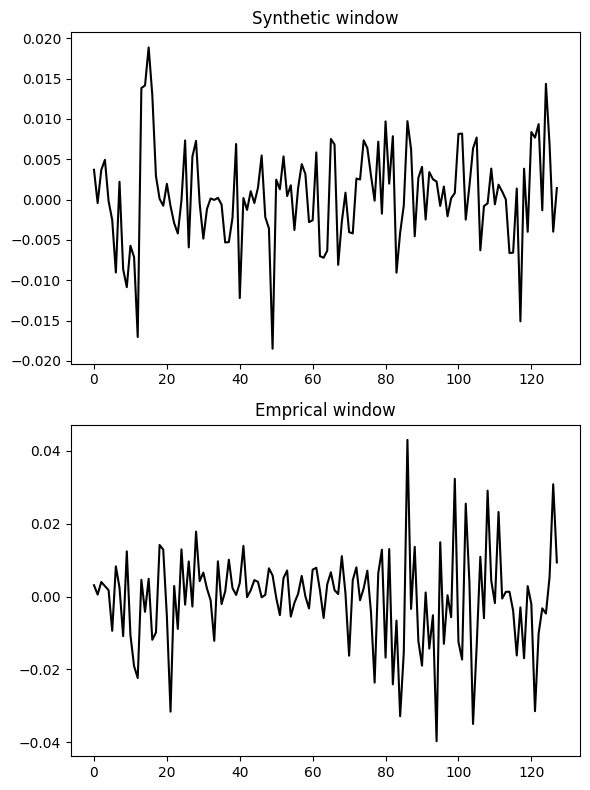

In [59]:
"""
  Note that the generated synthetic window cant be indexed by time since it doesnt preserve time index.
  We would label it as what a typical n-window return looked like from the training data.
"""

fig, ax = plt.subplots(figsize=(6, 8), nrows=2)

ax[0].plot(synthetic_data[0], c="black")
ax[1].plot(empirical_window[0], c="black")
ax[0].set_title("Synthetic window")
ax[1].set_title("Emprical window")

fig.tight_layout()
plt.show()

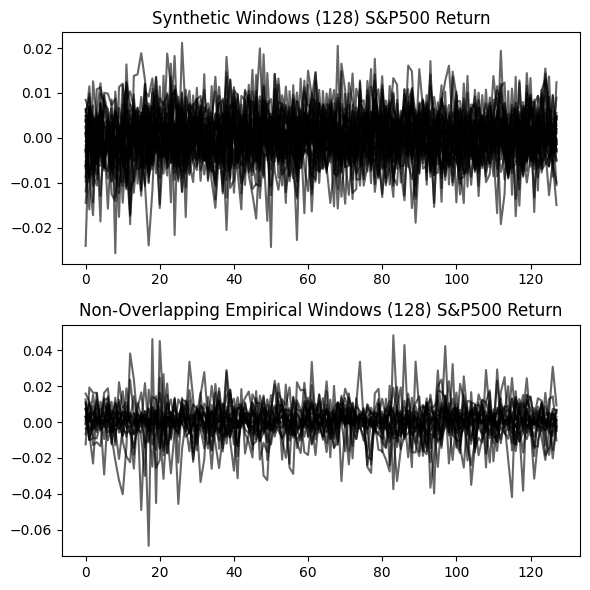

In [60]:
fig, ax = plt.subplots(figsize=(6, 6), nrows=2)
for i in range(len(synthetic_data)):
  ax[0].plot(synthetic_data[i], alpha=0.6, c="black")

ax[0].set_title(f"Synthetic Windows ({window}) S&P500 Return")

for i in range(len(empirical_window)):
  ax[1].plot(empirical_window[i], alpha=0.6, c="black")

ax[1].set_title(f"Non-Overlapping Empirical Windows ({window}) S&P500 Return")

fig.tight_layout()
plt.show()

### Stationarity Tests

In [61]:
def test_stationarity(windows, maxlag=10, regression="ct"):
  n = len(windows)
  result = []

  for i in range(n):
    res = adfuller(windows[i], maxlag=maxlag, regression=regression)
    result.append(res)

  return result

In [62]:
adf_emp = test_stationarity(empirical_window)
adf_syn = test_stationarity(synthetic_data)

In [63]:
for idx, res in enumerate(adf_emp):
  adf_statistic = res[0]
  critical_values = res[4]

  print("="*10 + f"ADF Test at window-{idx + 1}" + "="*10)
  print(f"ADF Test Statistic: {adf_statistic}")
  print(f"1% Critical Value: {critical_values['1%']}")
  print(f"5% Critical Value: {critical_values['5%']}")
  print(f"10% Critical Value: {critical_values['10%']}")

==========ADF Test at window-1==========
ADF Test Statistic: -11.572458298241918
1% Critical Value: -4.031882284616695
5% Critical Value: -3.44564246299154
10% Critical Value: -3.147663331295954
==========ADF Test at window-2==========
ADF Test Statistic: -12.274992277328897
1% Critical Value: -4.031882284616695
5% Critical Value: -3.44564246299154
10% Critical Value: -3.147663331295954
==========ADF Test at window-3==========
ADF Test Statistic: -9.034950939002485
1% Critical Value: -4.032477692253856
5% Critical Value: -3.4459262881778225
10% Critical Value: -3.1478290513383484
==========ADF Test at window-4==========
ADF Test Statistic: -6.137546411616755
1% Critical Value: -4.034323572017774
5% Critical Value: -3.446805955734612
10% Critical Value: -3.1483426003846597
==========ADF Test at window-5==========
ADF Test Statistic: -11.39513444195612
1% Critical Value: -4.031882284616695
5% Critical Value: -3.44564246299154
10% Critical Value: -3.147663331295954
==========ADF Test at w

In [64]:
rejections = 0

for idx, res in enumerate(adf_syn):
  adf_statistic = res[0]
  critical_values = res[4]

  print("="*10 + f"ADF Test at window-{idx + 1}" + "="*10)
  print(f"ADF Test Statistic: {adf_statistic}")
  print(f"1% Critical Value: {critical_values['1%']}")
  print(f"5% Critical Value: {critical_values['5%']}")
  print(f"10% Critical Value: {critical_values['10%']}")

  if adf_statistic < critical_values["5%"]:
    rejections += 1

==========ADF Test at window-1==========
ADF Test Statistic: -9.149787607840956
1% Critical Value: -4.031882284616695
5% Critical Value: -3.44564246299154
10% Critical Value: -3.147663331295954
==========ADF Test at window-2==========
ADF Test Statistic: -10.746914306599281
1% Critical Value: -4.031882284616695
5% Critical Value: -3.44564246299154
10% Critical Value: -3.147663331295954
==========ADF Test at window-3==========
ADF Test Statistic: -12.572602308667236
1% Critical Value: -4.031882284616695
5% Critical Value: -3.44564246299154
10% Critical Value: -3.147663331295954
==========ADF Test at window-4==========
ADF Test Statistic: -10.804111859470096
1% Critical Value: -4.031882284616695
5% Critical Value: -3.44564246299154
10% Critical Value: -3.147663331295954
==========ADF Test at window-5==========
ADF Test Statistic: -11.146509789229762
1% Critical Value: -4.031882284616695
5% Critical Value: -3.44564246299154
10% Critical Value: -3.147663331295954
==========ADF Test at wind

In [65]:
print(f"Rejection rate : {rejections / len(synthetic_data):.2f}")

Rejection rate : 0.97


### Theoretical Distribution Comparison  

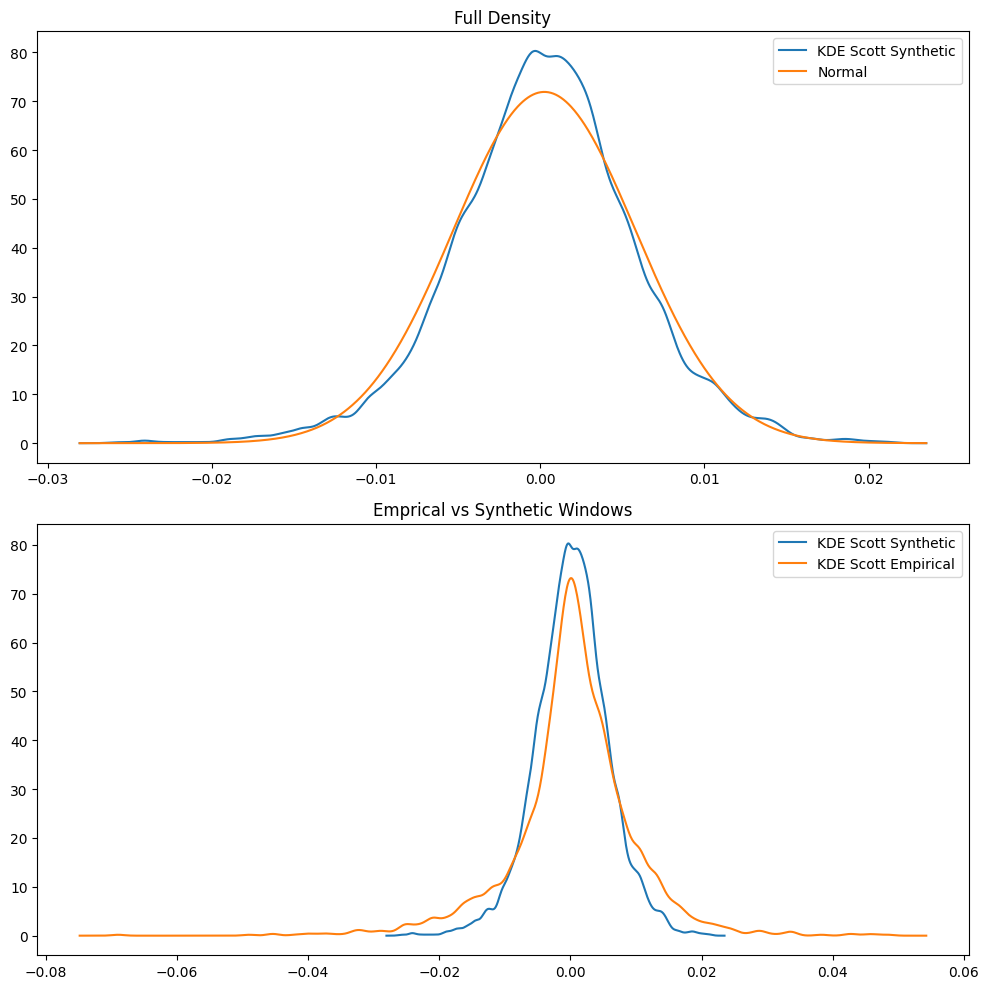

In [66]:
k = 3
std = synthetic_data.reshape(-1).std()
mu = synthetic_data.reshape(-1).mean()
n = min(len(synthetic_data.reshape(-1)), len(empirical_window.reshape(-1)))

data_min = synthetic_data.reshape(-1).min()
data_max = synthetic_data.reshape(-1).max()
padding = 0.05 * (data_max - data_min)

data_min_emp = empirical_window.reshape(-1).min()
data_max_emp = empirical_window.reshape(-1).max()
padding_emp = 0.05 * (data_max_emp - data_min_emp)

xmin = data_min - padding
xmax = data_max + padding

xmin_emp = data_min_emp - padding_emp
xmax_emp = data_max_emp + padding_emp

x = np.linspace(xmin, xmax, 1000)

x_emp = np.linspace(xmin_emp, xmax_emp, 1000)

kde = stats.gaussian_kde(synthetic_data.reshape(-1), bw_method=0.1)
kde_emp = stats.gaussian_kde(empirical_window.reshape(-1), bw_method=0.1)

# theoretical samples
norm = stats.norm(
    loc=mu,
    scale=std,
)

fig, ax = plt.subplots(figsize=(10, 10), nrows=2)
ax[0].plot(x, kde(x), label="KDE Scott Synthetic")
ax[0].plot(x, norm.pdf(x), label="Normal")
ax[0].set_title("Full Density")
ax[0].legend()

# ax[1].plot(x, kde(x), label="KDE Scott Synthetic")
# ax[1].plot(x, norm.pdf(x), label="Normal")
# ax[1].set_title("Tail Comparison")
# ax[1].set_yscale("log")
# ax[1].legend()

ax[1].plot(x, kde(x), label="KDE Scott Synthetic")
ax[1].plot(x_emp, kde_emp(x_emp), label="KDE Scott Empirical")
ax[1].set_title("Emprical vs Synthetic Windows")
# ax[1].set_yscale("log")
ax[1].legend()

# ax[3].plot(x, kde(x), label="KDE Scott Synthetic")
# ax[3].plot(x_emp, kde_emp(x_emp), label="KDE Scott Empirical")
# ax[3].set_title("Empirical vs Synthetic Tail Comparison")
# ax[3].set_yscale("log")
# ax[3].legend()


# plt.yscale("log")
plt.tight_layout()
plt.show()

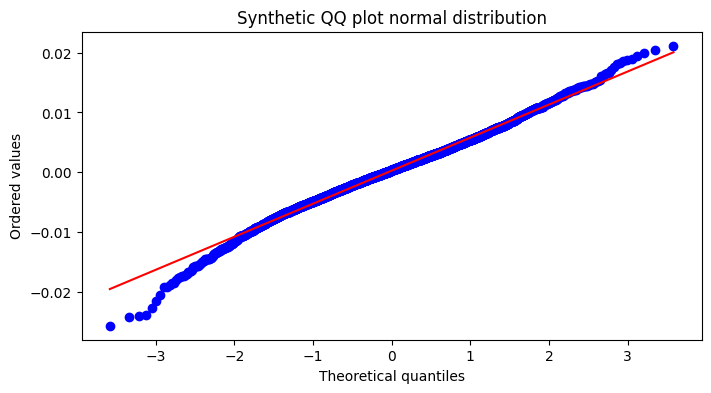

In [67]:
fig, ax = plt.subplots(figsize=(8, 4))

res = stats.probplot(synthetic_data.reshape(-1), plot=ax, dist="norm")
ax.set_title("Synthetic QQ plot normal distribution")
ax.set_ylabel("Ordered values")
ax.set_xlabel("Theoretical quantiles")
plt.show()

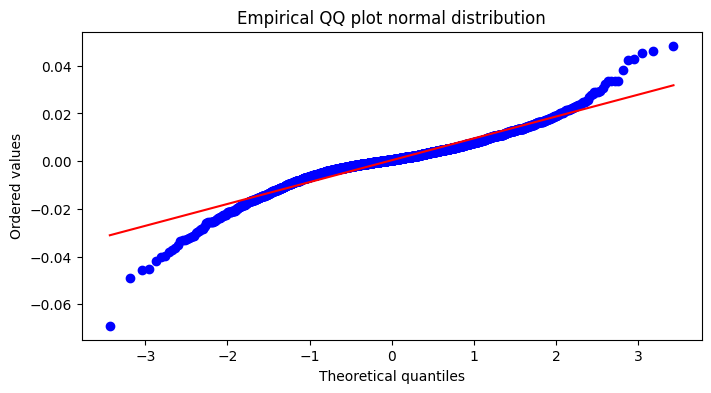

In [68]:
fig, ax = plt.subplots(figsize=(8, 4))

res = stats.probplot(empirical_window.reshape(-1), plot=ax, dist="norm")
ax.set_title("Empirical QQ plot normal distribution")
ax.set_ylabel("Ordered values")
ax.set_xlabel("Theoretical quantiles")
plt.show()

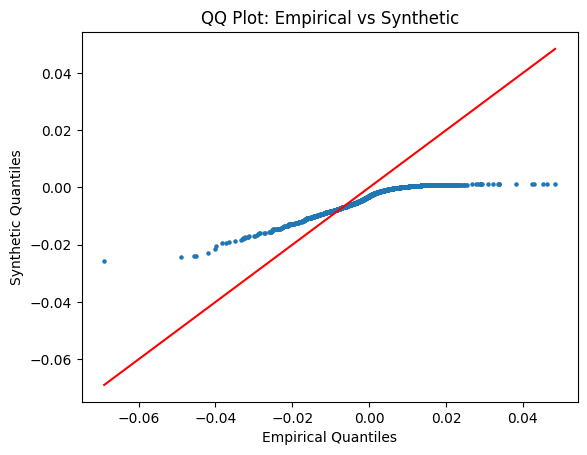

In [69]:
emp = np.sort(empirical_window.reshape(-1))
syn = np.sort(synthetic_data.reshape(-1))

n = min(len(emp), len(syn))

emp_q = emp[:n]
syn_q = syn[:n]

plt.scatter(emp_q, syn_q, s=5)
plt.plot(emp_q, emp_q, color='red') # reference target
plt.xlabel("Empirical Quantiles")
plt.ylabel("Synthetic Quantiles")
plt.title("QQ Plot: Empirical vs Synthetic")
plt.show()

In [70]:
kurtosis_emp = stats.kurtosis(empirical_window.reshape(-1))
skew_emp = stats.skew(empirical_window.reshape(-1))
kurtosis_syn = stats.kurtosis(synthetic_data.reshape(-1))
skew_syn = stats.skew(synthetic_data.reshape(-1))

print("="*10 + "Empirical" + "="*10)
print(f"Kurtosis : {kurtosis_emp}\nSkewness : {skew_emp}")

print("="*10 + "Synthetic" + "="*10)
print(f"Kurtosis : {kurtosis_syn}\nSkewness : {skew_syn}")

==========Empirical==========
Kurtosis : 4.584840460148701
Skewness : -0.47061797986958415
==========Synthetic==========
Kurtosis : 0.9695854510903006
Skewness : -0.15052132767895363


## Intra-Window Evaluation

In [71]:
lags=10

In [72]:
def compute_acf_matrix(windows, lags):
  return np.array([
      acf(w, nlags=lags, fft=True)
      for w in windows
  ])

def compute_ljung(windows, p_lag):
  """
    Returns:
    1. rejection_rate: rejection rate across windows
  """
  rejection_rate = 0

  for window in windows:
    res = sm.stats.acorr_ljungbox(window, lags=p_lag)
    lb_pvalue = res["lb_pvalue"].iloc[-1]
    rejection_rate += 1 if lb_pvalue < 0.05 else False

  return rejection_rate / len(windows)

def compare_acf_matrix(lag, acf_matrix):
  acf_value = acf_matrix[1:, lag]
  return np.mean(acf_value), np.std(acf_value)  

def compare_acf_matrices(lag, m1, m2):
  acf_m1 = m1[:, lag]
  acf_m2 = m2[:, lag]

  acf_m1_std = np.std(acf_m1)
  acf_m2_std = np.std(acf_m2)

  acf_m1_mean = np.mean(acf_m1)
  acf_m2_mean = np.mean(acf_m2)

  acf_m1_percentiles = np.percentile(m1[1:, lag], [25, 50, 75])
  acf_m2_percentiles = np.percentile(m2[1:, lag], [25, 50, 75])

  return {
    "m1_std": acf_m1_std,
    "m2_std": acf_m2_std,
    "m1_mean": acf_m1_mean,
    "m2_mean": acf_m2_mean,
    "m1_percentiles": acf_m1_percentiles,
    "m2_percentiles": acf_m2_percentiles,
  }

In [73]:
SAMPLES = 100
LAGS = 10
syn_reject_rate_list = []
rng = np.random.default_rng()

for i in range(SAMPLES):
  syn_sampled_window = rng.choice(synthetic_data, size=5, replace=False, axis=0)
  syn_rejection_rate = compute_ljung(syn_sampled_window, p_lag=LAGS)
  syn_reject_rate_list.append(syn_rejection_rate)

emp_reject_rate = compute_ljung(empirical_window, p_lag=LAGS)
syn_reject_std = np.std(syn_reject_rate_list)
syn_reject_mean = np.mean(syn_reject_rate_list)

In [74]:
print(f"Empirical rejection rate: ", emp_reject_rate)
print(f"Synthetic rejection rate mean: ", syn_reject_mean)
print(f"Synthetic rejection rate std: ", syn_reject_std)

Empirical rejection rate:  0.1111111111111111
Synthetic rejection rate mean:  0.11600000000000002
Synthetic rejection rate std:  0.1332066064427737


In [75]:
acf_emp = compute_acf_matrix(empirical_window, lags)
acf_syn = compute_acf_matrix(synthetic_data[:5], lags)

In [76]:
acf_emp

array([[ 1.        , -0.03850526, -0.04068015,  0.02622854,  0.01280045,
        -0.08814025, -0.05127248,  0.08263336, -0.14204256,  0.04500119,
        -0.01956798],
       [ 1.        , -0.09473942,  0.01425392, -0.05886653, -0.08927133,
         0.09640978, -0.11118587,  0.10452621, -0.06612649,  0.10543951,
        -0.02201713],
       [ 1.        ,  0.0223353 , -0.15174561,  0.04036878,  0.05692029,
        -0.08039033, -0.05661826,  0.08885507, -0.00759612, -0.14620503,
         0.01323392],
       [ 1.        , -0.14177452,  0.16755194, -0.21604084,  0.10873818,
        -0.22000988,  0.0772547 , -0.05088571,  0.0274778 , -0.07036684,
         0.12064506],
       [ 1.        , -0.02185651,  0.07330454, -0.04149298, -0.09160821,
        -0.15844046, -0.06353564, -0.04137925,  0.05595635,  0.06409308,
         0.18667106],
       [ 1.        ,  0.13827468, -0.11721494, -0.0763495 , -0.18380033,
        -0.01563287,  0.05004572, -0.03187962, -0.03053639,  0.11355289,
        -0.026

In [77]:
print(compare_acf_matrix(lag=2, acf_matrix=acf_emp))

(np.float64(-0.027375962134307125), np.float64(0.09743064062336265))


In [78]:
print(compare_acf_matrix(lag=2, acf_matrix=acf_syn))

(np.float64(0.016963396573147937), np.float64(0.04106657454390464))


In [79]:
compare_acf_matrices(lag=1, m1=acf_emp, m2=acf_syn)

{'m1_std': np.float64(0.0836944198444588),
 'm2_std': np.float64(0.10457834493155192),
 'm1_mean': np.float64(-0.04214025866854691),
 'm2_mean': np.float64(0.03143921678741578),
 'm1_percentiles': array([-0.10911693, -0.02742558,  0.0170839 ]),
 'm2_percentiles': array([-0.03016091,  0.0177893 ,  0.0358243 ])}

Figure(640x480)


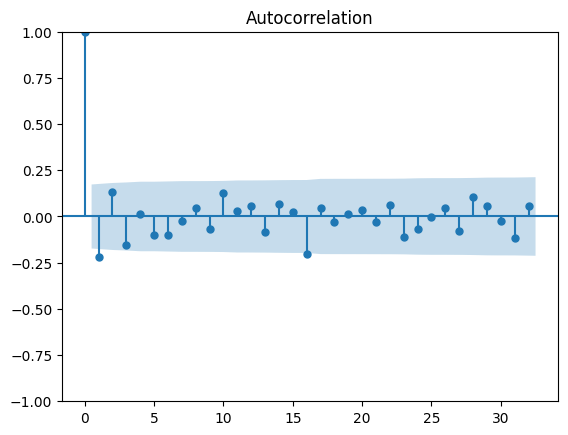

In [80]:
print(plot_acf(synthetic_data[15], lags=32))

Figure(640x480)


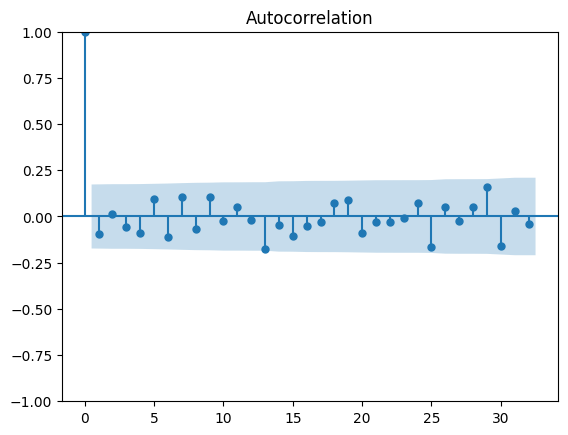

In [120]:
print(plot_acf(empirical_window[1], lags=32))

In [82]:
def get_residuals(window, lags=1):
    model = AutoReg(window, lags=lags, old_names=False).fit()
    return model.resid

res_emp = np.array([get_residuals(w) for w in empirical_window])
res_syn = np.array([get_residuals(w) for w in synthetic_data])

def arch_test(residuals, ddof):
    _, pval, _, _ = sm.stats.diagnostic.het_arch(residuals, ddof=ddof, nlags=10)
    return pval

# ddof = 2 because the residuals comes from regression model which have lag =1 and intercept 1 = 2
# Or common seeting for ddof = p + q for ARMA(p, q)
arch_emp = [arch_test(r, 2) for r in res_emp]
arch_syn = [arch_test(r, 2) for r in res_syn]

In [83]:
arch_emp, arch_syn

([np.float64(0.013115604542909762),
  np.float64(0.8286628968346181),
  np.float64(0.5584415934631344),
  np.float64(0.005095141077082506),
  np.float64(0.3463665157354441),
  np.float64(0.737706799756042),
  np.float64(0.7438534513117574),
  np.float64(0.8744797851284909),
  np.float64(0.3420850696404993),
  np.float64(0.020382157492974427),
  np.float64(0.3050955315034219),
  np.float64(0.03206977308110741),
  np.float64(0.12259312706230238),
  np.float64(0.8539970100500106),
  np.float64(0.7584156056164947),
  np.float64(3.1730265732818246e-05),
  np.float64(0.00010166972963460891),
  np.float64(0.02646437038095052)],
 [np.float64(0.11113916555543496),
  np.float64(0.9930919970107488),
  np.float64(0.9441933871851288),
  np.float64(0.842561830220971),
  np.float64(0.4029633019015797),
  np.float64(0.09274478788980194),
  np.float64(0.8590371908575432),
  np.float64(0.2101723522080873),
  np.float64(0.027793398713183086),
  np.float64(0.9179794746733525),
  np.float64(0.7648010527693

In [84]:
res_squared_emp = res_emp ** 2
res_squared_syn = res_syn ** 2

Figure(640x480)


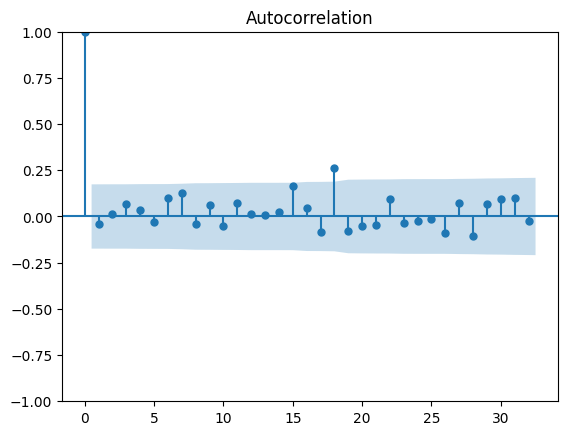

In [129]:
print(plot_acf(res_squared_emp[1], lags=32))

Figure(640x480)


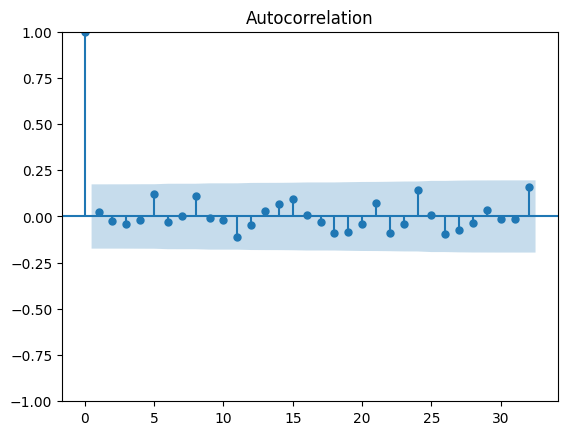

In [138]:
print(plot_acf(res_squared_syn[2], lags=32))

### Conclusion
1) The model generate stationarity fixed-window segment returns, which correlates with most financial return properties

2) Due to the small sample size (N=5) that leads to low statistical power, though conclusions are constrained by sample size. Given the computations of ljung box test rejection rate mean on repeated 5 random sampled windows, we could see that the rejection rate mean over-rejects compared to empirical windows tested on 10 lags. Both empirical and synthetic returns exhibit statistically significant autocorrelation as indicated by the Ljung–Box test. Also by the statistic comparion on mean, std, percentiles across windows within the same lag-p, it shows that although on overall ddpm captures the structure decay on the acf of returns, it overly misinterprets the scale magnitude of autocorrelation. Therefore, ddpm capture partial stylized facts.

3) Although the baseline model reproduces the general shape of the empirical return distribution, it fails to accurately capture the scale, as evidenced by deviations in the tails of the QQ plot as a marginal distribution comparison, suggesting an overestimation of extreme values

4) The ARCH test results, despite being based on a limited number of windows, indicate that volatility clustering is present in most empirical windows, supporting the use of GARCH-type models. In contrast, the synthetic data exhibits consistently stronger ARCH effects across all windows, suggesting that the model overestimates the strength and persistence of conditional heteroskedasticity.

### GARCH Evaluation under Fixed Window Segmentation

In [87]:
def compute_arch(windows, mean="zero", vol="GARCH", p=1, q=1):
  result = []
  n = len(windows)

  for i in range(n):
    model = arch_model(
      windows[i] * 100,
      mean=mean,
      vol=vol,
      p=p,
      q=q
    )

    res = model.fit(disp="off")
    result.append(res)

  return result

arch_emp = compute_arch(empirical_window)
arch_syn = compute_arch(synthetic_data)

In [88]:
window_emp = arch_emp[0]
print(window_emp.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.008
Vol Model:                      GARCH   Log-Likelihood:               -201.092
Distribution:                  Normal   AIC:                           408.184
Method:            Maximum Likelihood   BIC:                           416.740
                                        No. Observations:                  128
Date:                Fri, Apr 17 2026   Df Residuals:                      128
Time:                        15:29:21   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0328  3.149e-02      1.042      0.297 

In [89]:
window_syn = arch_syn[0]
print(window_syn.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.008
Vol Model:                      GARCH   Log-Likelihood:               -112.380
Distribution:                  Normal   AIC:                           230.760
Method:            Maximum Likelihood   BIC:                           239.316
                                        No. Observations:                  128
Date:                Fri, Apr 17 2026   Df Residuals:                      128
Time:                        15:29:22   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1453  6.526e-02      2.226  2.600e-02 [1.738e-0

In [90]:
metrics = []
alpha_emp = [res.params["alpha[1]"] for res in arch_emp]

for _ in range(1000):
    syn_subset = rng.choice(synthetic_data, size=5, replace=False, axis=0)
    arch_syn_subset = compute_arch(syn_subset)
    
    alpha_syn = [res.params["alpha[1]"] for res in arch_syn_subset]
    
    dist = stats.wasserstein_distance(alpha_emp, alpha_syn)
    metrics.append(dist)

Text(0.5, 1.0, 'Distribution of Distance (Empirical vs Synthetic)')

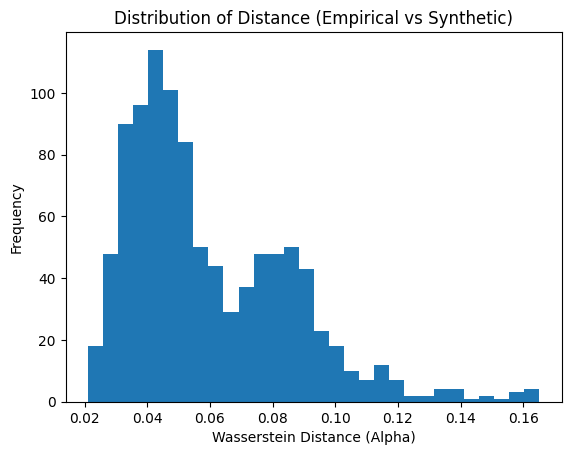

In [91]:
plt.hist(metrics, bins=30)
plt.xlabel("Wasserstein Distance (Alpha)")
plt.ylabel("Frequency")
plt.title("Distribution of Distance (Empirical vs Synthetic)")

Text(0.5, 1.0, 'Distribution of Distance (1000 trials)')

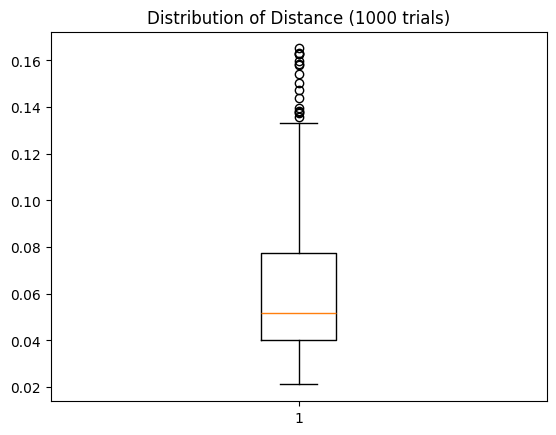

In [92]:
plt.boxplot(metrics)
plt.title("Distribution of Distance (1000 trials)")

In [93]:
x = np.sort(metrics)
y = np.arange(1, len(x)+1) / len(x)

Text(0, 0.5, 'CDF')

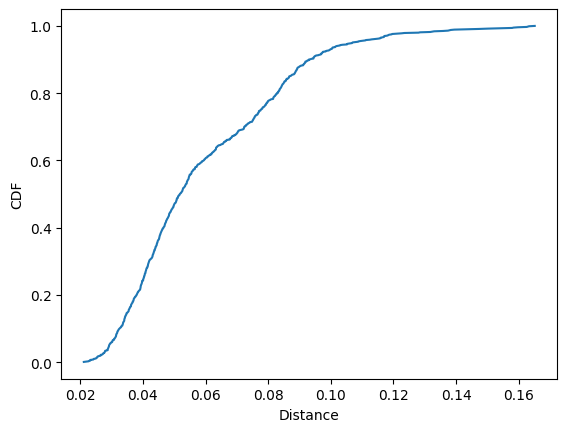

In [94]:
x = np.sort(metrics)
y = np.arange(1, len(x)+1) / len(x)

plt.plot(x, y)
plt.xlabel("Distance")
plt.ylabel("CDF")

In [95]:
SIM_DATA_PATH = dir / "data" / "sim_data_01.joblib"
SIM_DATA_PATH

WindowsPath('D:/CodingHenry/research_MBKM/data/sim_data_01.joblib')

In [96]:
sim_data = joblib.load(SIM_DATA_PATH)
sim_data

{'config': {'omega': 0.1,
  'alpha': 0.05,
  'beta': 0.9,
  'n_windows': 32,
  'n_data': 256},
 'sim_data': [         data  volatility    errors
  0   -1.008437    1.463513 -1.008437
  1    0.034818    1.441711  0.034818
  2   -0.047047    1.403830 -0.047047
  3   -0.203738    1.368859 -0.203738
  4   -2.340390    1.337338 -2.340390
  ..        ...         ...       ...
  251 -0.980580    1.278772 -0.980580
  252  0.208194    1.272717  0.208194
  253 -0.378256    1.248998 -0.378256
  254  0.114533    1.229288  0.114533
  255  0.882113    1.208590  0.882113
  
  [256 rows x 3 columns],
           data  volatility    errors
  0    1.201527    1.538913  1.201527
  1    0.191540    1.517765  0.191540
  2   -0.846674    1.474817 -0.846674
  3    2.766253    1.446865  2.766253
  4   -1.120326    1.538403 -1.120326
  ..        ...         ...       ...
  251 -1.671380    1.275802 -1.671380
  252  0.118312    1.305595  0.118312
  253 -0.826668    1.278601 -0.826668
  254  0.343751    1.267086 

In [97]:
sim_data_returns = [data["data"] for data in sim_data["sim_data"]]
sim_data_returns[0]

0     -1.008437
1      0.034818
2     -0.047047
3     -0.203738
4     -2.340390
         ...   
251   -0.980580
252    0.208194
253   -0.378256
254    0.114533
255    0.882113
Name: data, Length: 256, dtype: float64

In [98]:
arch_true = compute_arch(sim_data_returns)

d:\CodingHenry\research_MBKM\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.891e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\CodingHenry\research_MBKM\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.126e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\CodingHenry\research_MBKM\venv\Li

In [99]:
# baseline
garch_A = sim_data_returns[:16]
garch_B = sim_data_returns[16:]

len(garch_A), len(garch_B)

(16, 16)

In [100]:
arch_A = compute_arch(garch_A)
arch_B = compute_arch(garch_B)

d:\CodingHenry\research_MBKM\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.891e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\CodingHenry\research_MBKM\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.126e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\CodingHenry\research_MBKM\venv\Li

In [101]:
rho_A = [r.params["alpha[1]"] + r.params["beta[1]"] for r in arch_A]
rho_B = [r.params["alpha[1]"] + r.params["beta[1]"] for r in arch_B]

W_baseline = stats.wasserstein_distance(rho_A, rho_B)

In [102]:
W_baseline

np.float64(0.0023782185034228846)

In [103]:
alpha_syn = [r.params["alpha[1]"] for r in arch_syn]
alpha_true = [r.params["alpha[1]"] for r in arch_true]

beta_syn = [r.params["beta[1]"] for r in arch_syn]
beta_true = [r.params["beta[1]"] for r in arch_true]

rho_syn = [r.params["alpha[1]"] + r.params["beta[1]"] for r in arch_syn]
rho_true = [r.params["alpha[1]"] + r.params["beta[1]"] for r in arch_true]

dist_alpha = stats.wasserstein_distance(alpha_true, alpha_syn)
dist_beta  = stats.wasserstein_distance(beta_true, beta_syn)
dist_rho = stats.wasserstein_distance(rho_true, rho_syn)

In [104]:
dist_alpha, dist_beta

(np.float64(0.06571880369019716), np.float64(0.23245935322675354))

In [105]:
dist_rho

np.float64(0.16710114574916377)

### One-Step Windowed Forecasting GARCH

In [106]:
latest_emp_window = train_snp500[-window:]
test_snp500_window = test_snp500[:window]

In [107]:
syn_preds_windows = []

for syn_window in synthetic_data:
  syn_preds = one_step_rolling_forecast(syn_window * 100, test_snp500_window * 100) # scaling for stabilization in GARCH fitting
  syn_preds_windows.append(syn_preds)

emp_preds = one_step_rolling_forecast(latest_emp_window * 100, test_snp500_window * 100)

In [108]:
# scaled back
syn_preds_windows = np.array(syn_preds_windows) / 100
emp_preds = np.array(emp_preds) / 100

In [109]:
syn_preds_windows.shape

(32, 128)

In [110]:
syn_preds_windows

array([[0.00501311, 0.00779865, 0.00721827, ..., 0.00688294, 0.00644187,
        0.00659763],
       [0.00493832, 0.0050597 , 0.00509093, ..., 0.00713376, 0.00672932,
        0.00679631],
       [0.00586067, 0.00614226, 0.00619055, ..., 0.00795097, 0.00755668,
        0.00748218],
       ...,
       [0.00571205, 0.00621733, 0.00628779, ..., 0.00706162, 0.00667358,
        0.00674457],
       [0.00544257, 0.0055118 , 0.00552269, ..., 0.00762547, 0.00725741,
        0.00721449],
       [0.00495112, 0.00726107, 0.0063597 , ..., 0.00702507, 0.00654851,
        0.00655983]], shape=(32, 128))

In [111]:
syn_preds_windows_flattened = syn_preds_windows.flatten()

In [112]:
VaR_syn = -1.645 * syn_preds_windows_flattened
VaR_emp = -1.645 * emp_preds

print("Var Synthetic : ", VaR_syn)
print("Var Empirical : ", VaR_emp)

Var Synthetic :  [-0.00824656 -0.01282878 -0.01187405 ... -0.01155624 -0.0107723
 -0.01079091]
Var Empirical :  [-0.02655148 -0.0236933  -0.02085958 -0.01910647 -0.02526176 -0.02309092
 -0.02329024 -0.02100566 -0.01884892 -0.02552897 -0.02293435 -0.02011555
 -0.02846715 -0.0263302  -0.02487715 -0.02253295 -0.01979654 -0.02512279
 -0.05004959 -0.0431819  -0.03829486 -0.0338516  -0.03050163 -0.02665704
 -0.02290967 -0.01963095 -0.02000836 -0.01729949 -0.01445009 -0.02013597
 -0.01766602 -0.02828897 -0.0250579  -0.02236594 -0.02497373 -0.02536699
 -0.02273437 -0.02084435 -0.01976779 -0.02031933 -0.01870436 -0.01765671
 -0.02550923 -0.02470371 -0.02350084 -0.02124315 -0.0216556  -0.02270857
 -0.02084109 -0.01925555 -0.01996531 -0.02161435 -0.01978125 -0.01832042
 -0.01722604 -0.01829003 -0.02277121 -0.02070526 -0.01928332 -0.01941829
 -0.01768755 -0.01618785 -0.01489705 -0.01831013 -0.0178306  -0.02056535
 -0.02017567 -0.01841523 -0.01686878 -0.01688056 -0.01549324 -0.01736944
 -0.01842666

<function matplotlib.pyplot.show(close=None, block=None)>

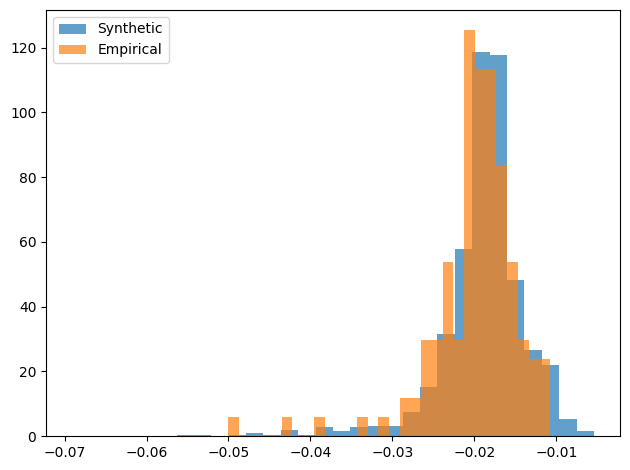

In [113]:
bins=30
plt.hist(VaR_syn, bins=bins, label="Synthetic", alpha=0.7, density=True)
plt.hist(VaR_emp, bins=bins, label="Empirical", alpha=0.7, density=True)
plt.legend()
plt.tight_layout()
plt.show

In [114]:
VaR_emp_95 = np.percentile(VaR_emp, [1, 2.5, 5])
VaR_syn_95 = np.percentile(VaR_syn, [1, 2.5, 5])

print("GARCH VaR Synthetic Percentiles : ", VaR_syn_95)
print("GARCH VaR Empirical Percentiles : ", VaR_emp_95)

GARCH VaR Synthetic Percentiles :  [-0.04232114 -0.03399773 -0.02725706]
GARCH VaR Empirical Percentiles :  [-0.0418624  -0.03326536 -0.02771779]


In [115]:
VaR_emp_95 = np.percentile(empirical_window.reshape(-1), [1, 2.5, 5])
VaR_syn_95 = np.percentile(synthetic_data[:len(empirical_window)].reshape(-1), [1, 2.5, 5])

print("VaR Synthetic Percentiles : ", VaR_syn_95)
print("VaR Empirical Percentiles : ", VaR_emp_95)

VaR Synthetic Percentiles :  [-0.01363115 -0.01073682 -0.00897831]
VaR Empirical Percentiles :  [-0.02857611 -0.02109099 -0.0157505 ]


<function matplotlib.pyplot.show(close=None, block=None)>

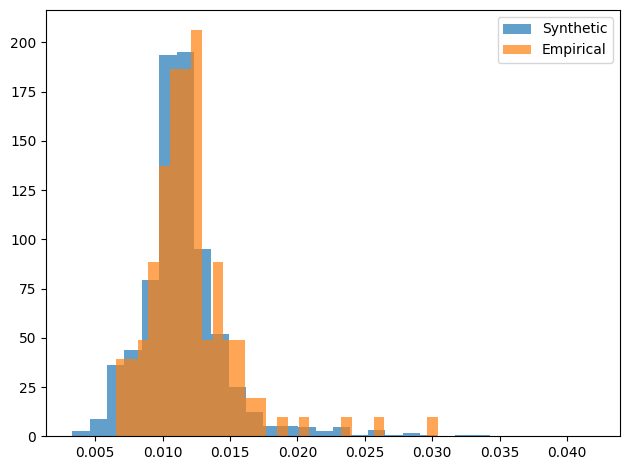

In [116]:
bins=30
plt.hist(syn_preds_windows_flattened, bins=bins, label="Synthetic", alpha=0.7, density=True)
plt.hist(emp_preds, bins=bins, label="Empirical", alpha=0.7, density=True)
plt.legend()
plt.tight_layout()
plt.show

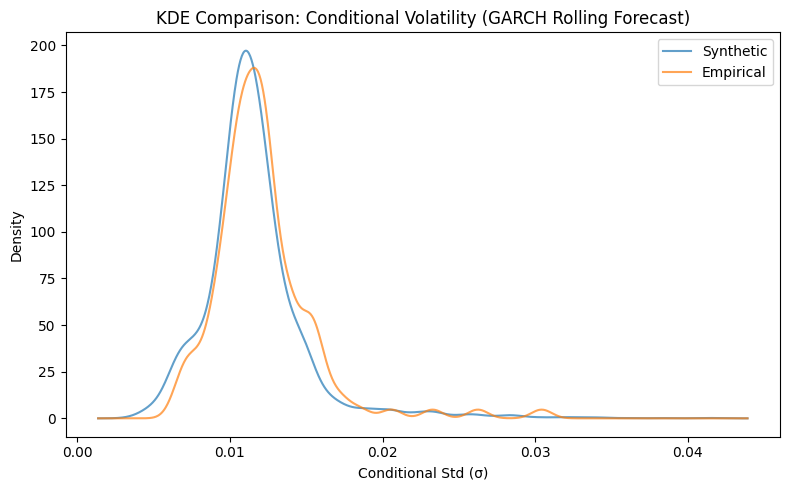

In [117]:
syn_flat = np.concatenate(syn_preds_windows_flattened) if isinstance(syn_preds_windows_flattened[0], (list, np.ndarray)) else np.array(syn_preds_windows_flattened)
emp_flat = np.array(emp_preds)

# n = len(emp_flat)
# if len(syn_flat) > n:
#     syn_flat = np.random.choice(syn_flat, size=n, replace=False)

global_min = min(syn_flat.min(), emp_flat.min())
global_max = max(syn_flat.max(), emp_flat.max())

padding = 0.05 * (global_max - global_min)

x = np.linspace(global_min - padding, global_max + padding, 1000)

bw = 0.2
kde_syn = stats.gaussian_kde(syn_flat, bw_method=bw)
kde_emp = stats.gaussian_kde(emp_flat, bw_method=bw)

plt.figure(figsize=(8, 5))

plt.plot(x, kde_syn(x), label="Synthetic", alpha=0.7)
plt.plot(x, kde_emp(x), label="Empirical", alpha=0.7)

plt.title("KDE Comparison: Conditional Volatility (GARCH Rolling Forecast)")
plt.xlabel("Conditional Std (σ)")
plt.ylabel("Density")

plt.legend()
plt.tight_layout()
plt.show()

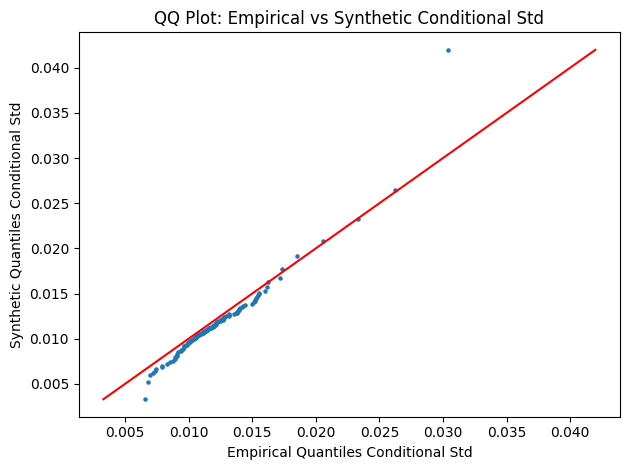

In [118]:
q = np.linspace(0, 1, len(emp_flat))

emp_q_pred = np.quantile(emp_flat, q)
syn_q_pred = np.quantile(syn_preds_windows_flattened, q)

plt.scatter(emp_q_pred, syn_q_pred, s=5)

min_val = min(emp_q_pred.min(), syn_q_pred.min())
max_val = max(emp_q_pred.max(), syn_q_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("Empirical Quantiles Conditional Std")
plt.ylabel("Synthetic Quantiles Conditional Std")
plt.title("QQ Plot: Empirical vs Synthetic Conditional Std")

plt.tight_layout()
plt.show()

In [119]:
W_conditional_std = stats.wasserstein_distance(emp_preds, syn_preds_windows_flattened)
W_conditional_std

np.float64(0.0006110948172441195)

### Conclusion
1) Based on the window rolling baseline GARCH Forecasting, we could see that our generated data reproduces the empirical conditional volatility distribution reasonably well. But our ddpm model seems to underestimate extreme volatilitity events based on the deviation on the top-quantiles of the qq-plot.